# EEP 153 Project 3 — Checkpoint
## Mali: Food Demand Estimation and Spending-Quartile Comparison

**Team:** Aaron Chang, Matt Arcaina, Tea Kalpakoff, Ash Htet, Omed Akbari  
**Country:** Mali  
**Research angle:** How do household food expenditure levels relate to diet composition and household demographic structure (as a proxy for fertility / dependent burden)?

### What this notebook does
1. Loads matched 2021-22 Mali household food expenditure and demographic data (6,125 households).
2. Estimates a Constant Frisch Elasticity (CFE) food demand system following Ligon's prototype.
3. Splits households into food-expenditure quartiles and compares household composition, food spending patterns, and nutrient intensity across quartiles.
4. Reports estimated income elasticities ($\beta$) and demographic effects ($\gamma$) from the demand system.

### Important framing for this checkpoint

- Quartiles are based on total food expenditure, not the CFE latent welfare measure. We plan to switch to latent welfare quartiles in the final version. For now, we refer to them as *spending quartiles*.
- The nutrient lookup table covers 20 of 132 food categories in our expenditure data, mostly staples (rice, millet, sorghum, oils, meats). Any nutrient computation should be interpreted as nutrients from these covered foods only, not total household dietary intake. We address this by reporting nutrient *intensity* (nutrients per CFA spent on covered foods) rather than nutrient totals.

In [1]:
%pip uninstall -y cfe
%pip install --upgrade CFEDemands

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import cfe
import matplotlib.pyplot as plt
Regression = cfe.Regression

## 2. Load raw data

In [30]:
x_raw = pd.read_csv("Mali - Food Expenditures (2021-22).csv")
d_raw = pd.read_csv("Mali - Household Characteristics.csv")

print(x_raw.head())
print(d_raw.head())

         t       m        i                   j  expenditure
0  2021-22  Bamako  1015001                 Ail          600
1  2021-22  Bamako  1015001           Aubergine           50
2  2021-22  Bamako  1015001        Banane douce          300
3  2021-22  Bamako  1015001  Beignets, galettes          300
4  2021-22  Bamako  1015001              Beurre         1100
         t      m     i  F 00-03  F 04-08  F 09-13  F 14-18  F 19-30  F 31-50  \
0  2017-18  Kayes  1001      NaN      2.0      1.0      NaN      2.0      NaN   
1  2017-18  Kayes  1002      3.0      NaN      NaN      2.0      2.0      1.0   
2  2017-18  Kayes  1003      NaN      3.0      4.0      4.0      1.0      2.0   
3  2017-18  Kayes  1004      6.0      3.0      5.0      6.0      5.0      4.0   
4  2017-18  Kayes  1005      1.0      3.0      1.0      4.0      2.0      3.0   

   F 51+  M 00-03  M 04-08  M 09-13  M 14-18  M 19-30  M 31-50  M 51+  M NA  \
0    NaN      1.0      2.0      NaN      NaN      NaN      1.0    Na

## 3. Restrict household data to 2021-22

In [31]:
print("x years:", x_raw["t"].unique())
print("d years:", d_raw["t"].unique())

d_raw = d_raw[d_raw["t"] == "2021-22"].copy()

print("x years after check:", x_raw["t"].unique())
print("d years after filter:", d_raw["t"].unique())

x years: ['2021-22']
d years: ['2017-18' '2021-22' '2018-19' '2014-15']
x years after check: ['2021-22']
d years after filter: ['2021-22']


## 4. Prepare food expenditures and household characteristics

In [32]:
if "expenditure" in x_raw.columns and "Expenditure" not in x_raw.columns:
    x_raw = x_raw.rename(columns={"expenditure": "Expenditure"})

In [33]:
x = x_raw.pivot_table(
    index=["i", "t", "m"],
    columns="j",
    values="Expenditure",
    aggfunc="sum"
)

x = x.replace(0, np.nan)
x_wide = x.copy()
y = np.log(x)

print(y.head())

j                   Ail  Ananas  Arachide  Attiéke  Aubergine  Autres agrumes  \
i    t       m                                                                  
1001 2021-22 Kayes  NaN     NaN       NaN      NaN        NaN             NaN   
1002 2021-22 Kayes  NaN     NaN       NaN      NaN   6.214608             NaN   
1003 2021-22 Kayes  NaN     NaN       NaN      NaN   5.298317             NaN   
1004 2021-22 Kayes  NaN     NaN       NaN      NaN   5.010635             NaN   
1005 2021-22 Kayes  NaN     NaN       NaN      NaN        NaN             NaN   

j                   Autres farines de céréales  Autres fruits  \
i    t       m                                                  
1001 2021-22 Kayes                         NaN            NaN   
1002 2021-22 Kayes                         NaN            NaN   
1003 2021-22 Kayes                         NaN            NaN   
1004 2021-22 Kayes                         NaN            NaN   
1005 2021-22 Kayes                        

In [34]:
d = d_raw.copy()
d.columns.name = "k"
d = d.set_index(["i", "t", "m"])
d = d.fillna(0)

print(d.head())

k                   F 00-03  F 04-08  F 09-13  F 14-18  F 19-30  F 31-50  \
i    t       m                                                             
1001 2021-22 Kayes      0.0      0.0      0.0      0.0      0.0      0.0   
1002 2021-22 Kayes      0.0      0.0      1.0      0.0      0.0      2.0   
1003 2021-22 Kayes      0.0      0.0      0.0      1.0      0.0      1.0   
1004 2021-22 Kayes      0.0      0.0      1.0      0.0      1.0      1.0   
1005 2021-22 Kayes      0.0      1.0      1.0      3.0      0.0      0.0   

k                   F 51+  M 00-03  M 04-08  M 09-13  M 14-18  M 19-30  \
i    t       m                                                           
1001 2021-22 Kayes    0.0      0.0      0.0      0.0      0.0      0.0   
1002 2021-22 Kayes    0.0      0.0      2.0      2.0      0.0      1.0   
1003 2021-22 Kayes    0.0      0.0      1.0      1.0      0.0      1.0   
1004 2021-22 Kayes    0.0      0.0      2.0      0.0      0.0      0.0   
1005 2021-22 Kayes    2

## 5. Match households across datasets

In [35]:
print("number of food observations:", len(x.index))
print("number of household observations:", len(d.index))
print("number of matching observations:", len(x.index.intersection(d.index)))

number of food observations: 6125
number of household observations: 6143
number of matching observations: 6125


In [36]:
common_index = x.index.intersection(d.index)

x = x.loc[common_index]
x_wide = x_wide.loc[common_index]
y = y.loc[common_index]
d = d.loc[common_index]

print("matched x shape:", x.shape)
print("matched d shape:", d.shape)

matched x shape: (6125, 132)
matched d shape: (6125, 17)


In [37]:
y = y.stack().dropna()
d = d.stack().dropna()

print(y.index.names)
print(d.index.names)

['i', 't', 'm', 'j']
['i', 't', 'm', 'k']


## 6. Estimate the food demand system

In [38]:
result = Regression(y=y, d=d)
pred = result.predicted_expenditures()

In [39]:
pred.head()

i     t        m      j                 
1001  2021-22  Kayes  Ail                    42.788809
                      Arachide              233.728890
                      Aubergine              63.663647
                      Beignets, galettes    130.616494
                      Biscuit               133.295455
dtype: float64

## 7. Construct wealth quartiles

In [40]:
hh_total = x_wide.sum(axis=1).rename("total_food_exp")

spending_quartile = pd.qcut(
    hh_total,
    4,
    labels=["Bottom spending quartile", "Q2", "Q3", "Top spending quartile"])

wealth_quartile = spending_quartile

wealth_df = hh_total.to_frame()
wealth_df["spending_quartile"] = spending_quartile
wealth_df.head()

,,,total_food_exp,spending_quartile
i,t,m,,
1001,2021-22,Kayes,4625.0,Bottom spending quartile
1002,2021-22,Kayes,3200.0,Bottom spending quartile
1003,2021-22,Kayes,3700.0,Bottom spending quartile
1004,2021-22,Kayes,2500.0,Bottom spending quartile
1005,2021-22,Kayes,7375.0,Q2


## 8. Build a household-level analysis table

In [41]:
analysis_df = d_raw.copy()
analysis_df = analysis_df.set_index(["i", "t", "m"])
analysis_df = analysis_df.fillna(0)
analysis_df = analysis_df.loc[common_index].copy()

analysis_df["total_food_exp"] = hh_total.loc[common_index]
analysis_df["wealth_quartile"] = wealth_quartile.loc[common_index]

analysis_df.head()

,,,F 00-03,F 04-08,F 09-13,F 14-18,F 19-30,F 31-50,F 51+,M 00-03,M 04-08,M 09-13,M 14-18,M 19-30,M 31-50,M 51+,M NA,log HSize,F NA,total_food_exp,wealth_quartile
i,t,m,,,,,,,,,,,,,,,,,,,
1001,2021-22,Kayes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.693147,0.0,4625.0,Bottom spending quartile
1002,2021-22,Kayes,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,2.197225,0.0,3200.0,Bottom spending quartile
1003,2021-22,Kayes,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.791759,0.0,3700.0,Bottom spending quartile
1004,2021-22,Kayes,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,1.791759,0.0,2500.0,Bottom spending quartile
1005,2021-22,Kayes,0.0,1.0,1.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.197225,0.0,7375.0,Q2


## 9. Compare household composition by wealth quartile

In [42]:
analysis_df.groupby("wealth_quartile", observed=False)[[
    "log HSize",
    "F 00-03", "M 00-03",
    "F 04-08", "M 04-08",
    "F 09-13", "M 09-13",
    "F 14-18", "M 14-18"
]].mean()

,log HSize,F 00-03,M 00-03,F 04-08,M 04-08,F 09-13,M 09-13,F 14-18,M 14-18
wealth_quartile,,,,,,,,,
Bottom spending quartile,1.737215,0.362630,0.397786,0.582031,0.608724,0.480469,0.503255,0.263021,0.328125
Q2,1.836053,0.389143,0.419882,0.598430,0.633748,0.488555,0.531066,0.367560,0.371485
Q3,1.854905,0.383007,0.432026,0.562092,0.689542,0.490850,0.525490,0.386928,0.418954
Top spending quartile,1.871680,0.345098,0.354248,0.628758,0.693464,0.528105,0.588235,0.377124,0.439216


## 10. Create child-burden proxy variables

In [43]:
analysis_df["young_children_0_3"] = analysis_df["F 00-03"] + analysis_df["M 00-03"]

analysis_df["children_0_18"] = (
    analysis_df["F 00-03"] + analysis_df["M 00-03"] +
    analysis_df["F 04-08"] + analysis_df["M 04-08"] +
    analysis_df["F 09-13"] + analysis_df["M 09-13"] +
    analysis_df["F 14-18"] + analysis_df["M 14-18"]
)

analysis_df.groupby("wealth_quartile", observed=False)[[
    "young_children_0_3",
    "children_0_18",
    "log HSize"
]].mean()

,young_children_0_3,children_0_18,log HSize
wealth_quartile,,,
Bottom spending quartile,0.760417,3.526042,1.737215
Q2,0.809026,3.799869,1.836053
Q3,0.815033,3.888889,1.854905
Top spending quartile,0.699346,3.954248,1.871680


**This Table:**
    Top-quartile households are slightly larger on average (log HSize 1.87 vs 1.74, implying about 6.5 vs 5.7 members) and have slightly more children aged 0–18 (3.95 vs 3.53). However, the count of very young children (ages 0–3) is essentially flat across quartiles (0.76 vs 0.70). This means our data does not show a strong fertility-style gradient by spending — the differences are small and not monotonic. We will revisit this after switching to the CFE latent welfare quartiles in the final version.

## 11. Compare food expenditures by wealth quartile

In [58]:
tmp = x_wide.loc[common_index].copy()
tmp["spending_quartile"] = wealth_quartile.loc[common_index]

food_means = tmp.groupby("spending_quartile", observed=False).mean(numeric_only=True).T

bottom_top = food_means[["Bottom spending quartile", "Top spending quartile"]].copy()
bottom_top["difference"] = (
    bottom_top["Top spending quartile"] - bottom_top["Bottom spending quartile"])

bottom_top.sort_values("difference", ascending=False).head(20)

spending_quartile,Bottom spending quartile,Top spending quartile,difference
j,,,
Riz local Gambiaka,752.477064,20985.544676,20233.067611
Riz brisé importé,842.717391,18981.877256,18139.159865
Mil,754.207921,17122.583893,16368.375972
Riz importé parfumé,858.888889,16729.976852,15871.087963
Sorgho,442.500000,13971.153846,13528.653846
Maïs,523.809524,13098.721591,12574.912067
Riz local fumé,898.728814,12401.676829,11502.948016
Autres viandes,750.000000,4833.333333,4083.333333
Gibiers,650.000000,4500.000000,3850.000000


## 12. Largest absolute expenditure gaps between top and bottom spending quartiles

The chart below shows the 10 food categories with the largest absolute spending difference between top- and bottom-quartile households. The biggest gaps are concentrated in staple grains (multiple rice varieties, millet, sorghum, maize) and a few protein sources. This is consistent with Engel's Law: as households move from the bottom to the top of the food-spending distribution, they spend much more on staples in absolute terms, but staples become a smaller share of their food budget.

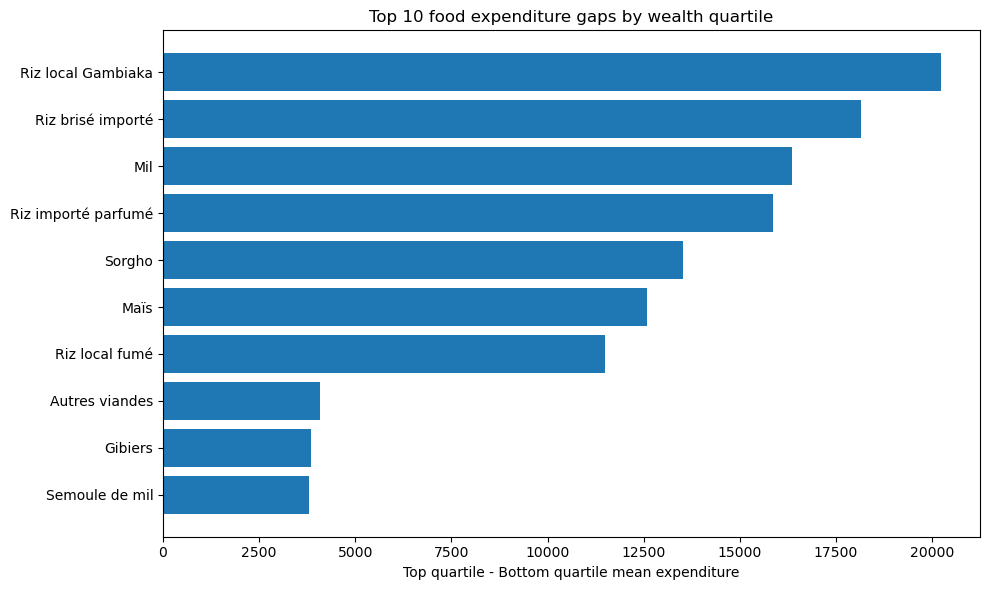

In [45]:
top10 = bottom_top.sort_values("difference", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10.index, top10["difference"])
plt.xlabel("Top quartile - Bottom quartile mean expenditure")
plt.title("Top 10 food expenditure gaps by wealth quartile")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 12A. Convert covered-food expenditures into estimated quantities and nutrients

For the 20 food categories that appear in our nutrient lookup table, we convert household expenditure to physical quantity and then to nutrient intake. The conversion is:

$$\text{quantity (kg)} = \frac{\text{expenditure (CFA)}}{\text{price (CFA/kg)}}$$

$$\text{nutrient} = \frac{\text{quantity (g)}}{100} \times \text{nutrient per 100g}$$

The lookup table prices are in CFA per kilogram, which we verify against the 2021-22 Food Prices survey sheet in Section 13 below.

In [46]:
nutri_raw = pd.read_csv("Mali Food nutrients and prices - Sheet1.csv")

nutri_raw = nutri_raw.rename(columns={
    "French name": "measure",
    "Unnamed: 1": "unit"})

print(nutri_raw.head())
print(nutri_raw.shape)
print(nutri_raw.columns.tolist())

                            measure  unit  \
0                      English name   NaN   
1                        Sodium, Na    mg   
2  Energy (Atwater General Factors)  kcal   
3                           Protein     g   
4              Fiber, total dietary     g   

                                Riz local Gambiaka  \
0  Local Gambiaka Rice (nutrients from White rice)   
1                                                0   
2                                              359   
3                                             7.04   
4                                              0.1   

                                   Riz brisé importé                   Mil  \
0  \r\nImported broken rice (nutrients from White...  millet (whole grain)   
1                                                  0                 < 2.5   
2                                                359                   376   
3                                               7.04                    10   
4             

In [47]:
food_cols = nutri_raw.columns[2:]

price_lookup = (
    nutri_raw[nutri_raw["measure"] == "Price, avg across regions"][food_cols]
    .T
    .reset_index())
price_lookup.columns = ["food", "price_avg"]
price_lookup["price_avg"] = pd.to_numeric(price_lookup["price_avg"], errors="coerce")

nutrient_rows = nutri_raw[
    nutri_raw["measure"].notna() &
    ~nutri_raw["measure"].isin([
        "English name",
        "**Per 100g",
        "Price, avg across regions"])].copy()

nutrient_long = nutrient_rows.melt(
    id_vars=["measure", "unit"],
    value_vars=food_cols,
    var_name="food",
    value_name="amount_per_100g")

nutrient_long["amount_per_100g"] = pd.to_numeric(
    nutrient_long["amount_per_100g"],
    errors="coerce")

print(price_lookup.head())
print(nutrient_long.head())

                  food  price_avg
0   Riz local Gambiaka    1860.51
1    Riz brisé importé    1683.02
2                  Mil    1063.25
3  Riz importé parfumé    1774.58
4               Sorgho     709.23
                            measure  unit                food  amount_per_100g
0                        Sodium, Na    mg  Riz local Gambiaka             0.00
1  Energy (Atwater General Factors)  kcal  Riz local Gambiaka           359.00
2                           Protein     g  Riz local Gambiaka             7.04
3              Fiber, total dietary     g  Riz local Gambiaka             0.10
4                       Folate, DFE    µg  Riz local Gambiaka              NaN


In [48]:
foods_in_lookup = [food for food in price_lookup["food"] if food in x_wide.columns]

print("Number of foods in lookup that match x_wide:", len(foods_in_lookup))
print(foods_in_lookup)

Number of foods in lookup that match x_wide: 20
['Riz local Gambiaka', 'Riz brisé importé', 'Mil', 'Riz importé parfumé', 'Sorgho', 'Maïs', 'Riz local fumé', 'Autres viandes', 'Gibiers', 'Semoule de mil', 'Poulet sur pied', 'Farine de blé', 'Huile de coton', 'Farine de mil', 'Viande de mouton', 'Huile de palme', 'Semoule de mais', 'Viande de chèvre', 'Sucre poudre', "Huile d'arachide"]


In [49]:
price_series = (
    price_lookup.set_index("food")
    .loc[foods_in_lookup, "price_avg"])

food_exp_lookup = x_wide[foods_in_lookup].fillna(0).copy()

quantity_kg = food_exp_lookup.div(price_series, axis=1)
quantity_g = quantity_kg * 1000

print(quantity_g.head())

j                   Riz local Gambiaka  Riz brisé importé  Mil  \
i    t       m                                                   
1001 2021-22 Kayes                 0.0                0.0  0.0   
1002 2021-22 Kayes                 0.0                0.0  0.0   
1003 2021-22 Kayes                 0.0                0.0  0.0   
1004 2021-22 Kayes                 0.0                0.0  0.0   
1005 2021-22 Kayes                 0.0                0.0  0.0   

j                   Riz importé parfumé  Sorgho  Maïs  Riz local fumé  \
i    t       m                                                          
1001 2021-22 Kayes                  0.0     0.0   0.0             0.0   
1002 2021-22 Kayes                  0.0     0.0   0.0             0.0   
1003 2021-22 Kayes                  0.0     0.0   0.0             0.0   
1004 2021-22 Kayes                  0.0     0.0   0.0             0.0   
1005 2021-22 Kayes                  0.0     0.0   0.0             0.0   

j                   Autre

In [50]:
selected_nutrients = [
    "Energy (Atwater General Factors)",
    "Protein",
    "Iron, Fe",
    "Zinc, Zn",
    "Vitamin A, RAE"]

nutrient_pivot = (
    nutrient_long[nutrient_long["measure"].isin(selected_nutrients)]
    .pivot_table(
        index="food",
        columns="measure",
        values="amount_per_100g",
        aggfunc="first")
    .reindex(foods_in_lookup)
    .fillna(0))

household_nutrients = pd.DataFrame(index=quantity_g.index)

for nutrient in selected_nutrients:
    total = pd.Series(0.0, index=quantity_g.index)

    for food in foods_in_lookup:
        nutrient_per_100g = nutrient_pivot.loc[food, nutrient]
        total = total + (quantity_g[food] / 100) * nutrient_per_100g
    household_nutrients[nutrient] = total
household_nutrients.head()

,,,Energy (Atwater General Factors),Protein,"Iron, Fe","Zinc, Zn","Vitamin A, RAE"
i,t,m,,,,,
1001,2021-22,Kayes,1915.557095,0.0,0.247488,0.049498,0.0
1002,2021-22,Kayes,2131.702565,0.0,0.024114,0.000000,0.0
1003,2021-22,Kayes,11433.695774,0.0,0.388021,0.129340,0.0
1004,2021-22,Kayes,3811.231925,0.0,0.129340,0.043113,0.0
1005,2021-22,Kayes,0.000000,0.0,0.000000,0.000000,0.0


## 13. Diagnostics: lookup coverage and price-unit verification

Before interpreting any nutrient results, we run two diagnostics:

1. Coverage diagnostic — what fraction of each household's food spending is on foods our lookup table actually covers? If coverage differs systematically across quartiles, then comparing nutrient totals across quartiles is misleading.
2. Price-unit verification — do the lookup prices actually correspond to CFA per kilogram, as we assumed?

The results below justify the framing we use for the rest of the notebook: we report nutrient intensity (nutrients per CFA of covered-food spending) rather than nutrient totals.

In [51]:
analysis_ckpt = analysis_df.copy()
analysis_ckpt["spending_quartile"] = spending_quartile.loc[analysis_ckpt.index]
analysis_ckpt["hh_size"] = np.exp(analysis_ckpt["log HSize"])

analysis_ckpt[["total_food_exp", "hh_size", "spending_quartile"]].head()

,,,total_food_exp,hh_size,spending_quartile
i,t,m,,,
1001,2021-22,Kayes,4625.0,2.0,Bottom spending quartile
1002,2021-22,Kayes,3200.0,9.0,Bottom spending quartile
1003,2021-22,Kayes,3700.0,6.0,Bottom spending quartile
1004,2021-22,Kayes,2500.0,6.0,Bottom spending quartile
1005,2021-22,Kayes,7375.0,9.0,Q2


In [52]:
mapped_food_exp = x_wide[foods_in_lookup].fillna(0).sum(axis=1).rename("mapped_food_exp")
n_mapped_foods = (x_wide[foods_in_lookup].fillna(0) > 0).sum(axis=1).rename("n_mapped_foods_purchased")

analysis_ckpt["mapped_food_exp"] = mapped_food_exp.reindex(analysis_ckpt.index)
analysis_ckpt["mapped_food_share"] = (
    analysis_ckpt["mapped_food_exp"] / analysis_ckpt["total_food_exp"].replace(0, np.nan))
analysis_ckpt["n_mapped_foods_purchased"] = n_mapped_foods.reindex(analysis_ckpt.index)

coverage_by_quartile = analysis_ckpt.groupby("spending_quartile", observed=False)[[
    "total_food_exp",
    "mapped_food_exp",
    "mapped_food_share",
    "n_mapped_foods_purchased"]].mean()

coverage_by_quartile.round(3)

,total_food_exp,mapped_food_exp,mapped_food_share,n_mapped_foods_purchased
spending_quartile,,,,
Bottom spending quartile,3244.814,918.584,0.299,1.918
Q2,8696.962,2395.000,0.271,2.710
Q3,21207.418,11854.552,0.527,3.238
Top spending quartile,53921.503,36506.258,0.668,4.141


**Results.** The bottom spending quartile has only **~30%** of its food spending on lookup-covered foods, and purchases an average of **1.9** distinct covered foods. The top spending quartile has **~67%** of spending on covered foods, purchasing an average of **4.1** covered foods. Top-quartile households also spend much more in absolute CFA on covered foods.

**Implication.** Comparing nutrient *totals* across quartiles would conflate two things: (a) actual differences in nutrient intake, and (b) differences in how well our lookup table covers each group's food basket. Bottom-quartile households appear to have very low nutrient totals partly because they buy more vegetables, condiments, and prepared foods that are not in our lookup. To make a fair comparison, we report nutrient intensity per 1000 CFA of covered-food spending in the next cell.

In [53]:
household_nutrients_mapped = household_nutrients.copy()

per_1000_cfa = household_nutrients_mapped.div(
    mapped_food_exp.replace(0, np.nan), axis=0) * 1000

per_1000_cfa.columns = [
    f"{col} per 1000 CFA" for col in per_1000_cfa.columns]

analysis_ckpt = analysis_ckpt.join(household_nutrients_mapped, how="left")
analysis_ckpt = analysis_ckpt.join(per_1000_cfa, how="left")

intensity_cols = per_1000_cfa.columns.tolist()
covered_intensity_by_quartile = analysis_ckpt.groupby(
    "spending_quartile", observed=False)[intensity_cols].mean()

print("Nutrient intensity by spending quartile (covered foods only):")
print("Each value = nutrient delivered per 1000 CFA spent on covered foods.")
covered_intensity_by_quartile.round(2)

Nutrient intensity by spending quartile (covered foods only):
Each value = nutrient delivered per 1000 CFA spent on covered foods.


,Energy (Atwater General Factors) per 1000 CFA,Protein per 1000 CFA,"Iron, Fe per 1000 CFA","Zinc, Zn per 1000 CFA","Vitamin A, RAE per 1000 CFA"
spending_quartile,,,,,
Bottom spending quartile,5350.27,25.51,3.35,5.04,0.03
Q2,5054.61,32.84,4.51,6.39,0.46
Q3,3612.09,38.18,4.33,7.29,0.78
Top spending quartile,3109.23,51.63,8.04,10.37,0.44


**Reading this table.** Two patterns stand out:

- **Calories per CFA falls** as we move from bottom to top quartile. Poorer households get more raw calories per CFA spent on staples, they buy cheaper energy-dense grains.
- Protein, iron, and zinc per CFA rise across quartiles. Wealthier households trade cheap calories for more nutrient-dense foods, including meats and other higher-value covered foods.

This is the meaningful, defensible result: even within the foods our lookup covers, the composition of staple spending shifts toward nutrient density as household food budgets rise. This pattern is consistent with dietary upgrading.

In [54]:
from pathlib import Path

prices_2021 = None

if Path("Mali - Food Prices (2021-22).csv").exists():
    prices_2021 = pd.read_csv("Mali - Food Prices (2021-22).csv")
elif Path("Mali.xlsx").exists():
    prices_2021 = pd.read_excel("Mali.xlsx", sheet_name="Food Prices (2021-22)")
else:
    print("Could not find 'Mali - Food Prices (2021-22).csv' or 'Mali.xlsx' in the working directory.")

if prices_2021 is not None:
    prices_2021.columns = [c.strip() for c in prices_2021.columns]

    mapped_prices = prices_2021[prices_2021["j"].isin(foods_in_lookup)].copy()

    print("Overall unit distribution in the 2021-22 price sheet:")
    display(prices_2021["u"].value_counts(dropna=False).to_frame("count"))

    survey_price_avg = mapped_prices.groupby("j")["price"].mean().rename("survey_avg_price")
    lookup_price_avg = price_series.rename("lookup_price_avg")

    price_check = pd.concat([lookup_price_avg, survey_price_avg], axis=1)
    price_check["lookup_over_survey"] = (
        price_check["lookup_price_avg"] / price_check["survey_avg_price"])
    price_check["pct_diff"] = 100 * (
        price_check["lookup_price_avg"] - price_check["survey_avg_price"]) / price_check["survey_avg_price"]

    print("\nLookup prices versus survey-average prices for covered foods:")
    display(price_check.round(6))

Overall unit distribution in the 2021-22 price sheet:


,count
u,
kg,1007



Lookup prices versus survey-average prices for covered foods:


,lookup_price_avg,survey_avg_price,lookup_over_survey,pct_diff
Riz local Gambiaka,1860.51,1860.505528,1.000002,0.000240
Riz brisé importé,1683.02,1683.015382,1.000003,0.000274
Mil,1063.25,1063.249471,1.000000,0.000050
Riz importé parfumé,1774.58,1774.581719,0.999999,-0.000097
Sorgho,709.23,709.225152,1.000007,0.000684
Maïs,697.81,697.812327,0.999997,-0.000333
Riz local fumé,1246.88,1246.878469,1.000001,0.000123
Autres viandes,6061.50,6061.495971,1.000001,0.000066
Gibiers,1400.30,1400.298280,1.000001,0.000123
Semoule de mil,692.49,692.491834,0.999997,-0.000265


**Price verification result.** All covered-food observations in the 2021-22 price sheet are reported in kilograms, and lookup prices match survey-average prices essentially exactly. The expenditure-to-quantity conversion used above is therefore directly validated against the source survey data.

## 14. Inspect estimated income elasticities 
Higher $\beta$ means demand for that food rises more strongly with household budget. Lower $\beta$ means the food behaves more like a necessity.

Estimated Frisch elasticities for 51 foods
Range: 0.33 to 2.30

Most income-INELASTIC foods (necessities):
j
Igname                0.33
Viande de poulet      0.34
Feuilles de Fakoye    0.36
Pâtes alimentaires    0.39
Pain                  0.40
Salade                0.41
Concombre             0.44
Beignets, galettes    0.48
Pastèque              0.55
Mangue                0.63
Name: beta, dtype: float64

Most income-ELASTIC foods (luxuries):
j
Sucre poudre           1.17
Soumbala               1.22
Oignon                 1.32
Mayonnaise             1.36
Cube alimentaire       1.52
Concentré de tomate    1.52
Huile de palme         1.58
Riz local Gambiaka     1.78
Huile d'arachide       2.06
Mil                    2.30
Name: beta, dtype: float64


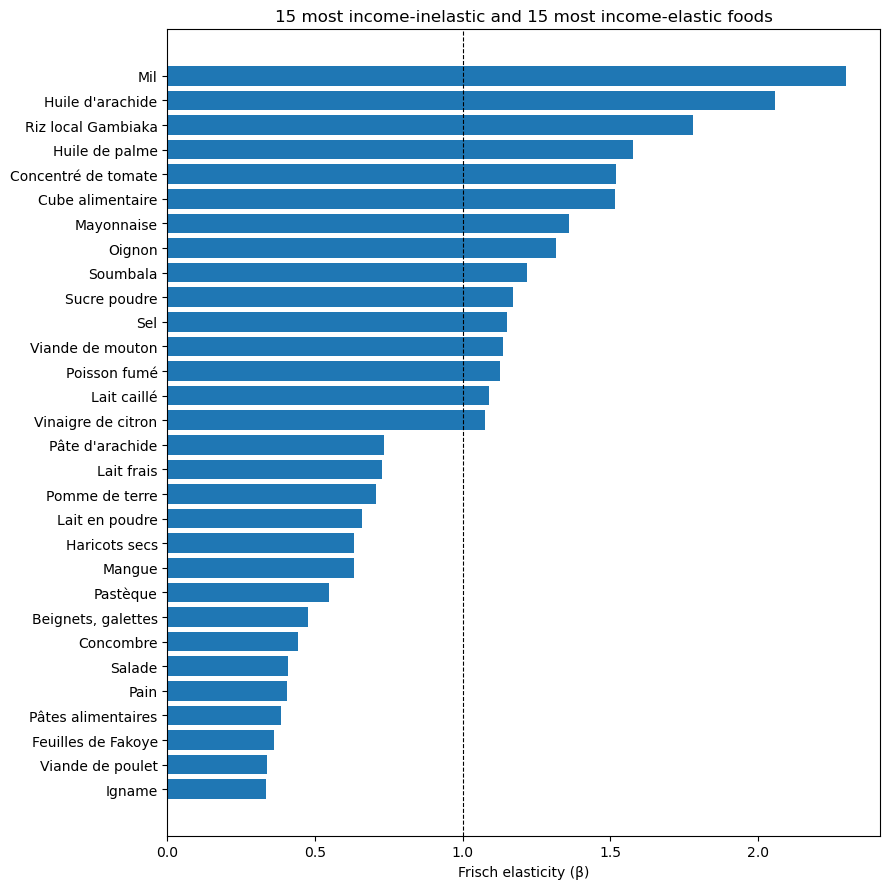

In [55]:
beta_obj = result.get_beta() if hasattr(result, "get_beta") else getattr(result, "beta", None)

if isinstance(beta_obj, pd.DataFrame):
    beta_series = beta_obj.iloc[:, 0]
else:
    beta_series = pd.Series(beta_obj)

beta_series = beta_series.dropna().sort_values()

print(f"Estimated Frisch elasticities for {len(beta_series)} foods")
print(f"Range: {beta_series.min():.2f} to {beta_series.max():.2f}")

print("\nMost income-INELASTIC foods (necessities):")
print(beta_series.head(10).round(2))

print("\nMost income-ELASTIC foods (luxuries):")
print(beta_series.tail(10).round(2))

extremes = pd.concat([beta_series.head(15), beta_series.tail(15)])

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(extremes.index.astype(str), extremes.values)
ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Frisch elasticity (β)")
ax.set_title("15 most income-inelastic and 15 most income-elastic foods")
plt.tight_layout()
plt.show()

**Reading the elasticities.** A Frisch elasticity above 1 means demand for that food rises more than proportionally with household budget — a luxury-like good. Below 1 means a necessity-like good whose demand rises more slowly with budget.

In this Mali checkpoint, the most elastic foods are items whose demand expands strongly as household budgets rise, while the least elastic foods are basic or traditional items whose demand changes less with income.

## 15. Inspect demographic effects

These coefficients show how household composition shifts food demand independent of total budget.

In [56]:
gamma_obj = getattr(result, "gamma", None)

if isinstance(gamma_obj, pd.DataFrame):
    gamma_df = gamma_obj.copy()
elif isinstance(gamma_obj, pd.Series):
    if gamma_obj.index.nlevels > 1:
        gamma_df = gamma_obj.unstack()
    else:
        gamma_df = gamma_obj.to_frame("gamma")
else:
    gamma_df = pd.DataFrame(gamma_obj)

print("Gamma coefficients (demographic effects on log expenditure)")
print("Shape:", gamma_df.shape)

display(gamma_df.iloc[:8, :8])

gamma_numeric = gamma_df.select_dtypes(include=[np.number])
if not gamma_numeric.empty:
    top_gamma = gamma_numeric.abs().stack().sort_values(ascending=False).head(15)
    print("\nLargest absolute gamma coefficients:")
    display(top_gamma.to_frame("abs_gamma"))

Gamma coefficients (demographic effects on log expenditure)
Shape: (51, 18)


k,F 00-03,F 04-08,F 09-13,F 14-18,F 19-30,F 31-50,F 51+,M 00-03
j,,,,,,,,
Ail,0.002257,0.042728,-0.005574,-0.031874,0.058698,0.085990,0.026391,-0.031016
Arachide,-0.081183,-0.042509,-0.009180,-0.013529,-0.022805,0.030580,-0.024665,-0.188477
Aubergine,-0.122927,0.073554,-0.028106,0.024601,0.050710,0.055721,-0.039450,-0.033435
"Beignets, galettes",-0.109704,-0.013403,-0.023095,-0.007230,-0.006674,-0.073517,-0.010645,-0.055647
Biscuit,-0.066954,0.021902,-0.004779,0.125829,0.027955,-0.015316,-0.051869,-0.182514
Café,-0.106764,-0.057777,-0.107250,-0.008784,0.045101,-0.037457,-0.138273,-0.132233
"Caramel, bonbons, confiseries",-0.159526,-0.088186,0.111675,-0.068651,0.043516,0.010765,0.059734,-0.136079
Carotte,-0.057567,0.072939,-0.074687,-0.001673,-0.050197,0.107284,0.063619,-0.119745



Largest absolute gamma coefficients:


,,abs_gamma
j,k,
Riz local Gambiaka,Constant,8.405212
Viande de poulet,Constant,7.744041
Mil,Constant,7.717693
Riz local fumé,Constant,7.690366
Viande de mouton,Constant,7.088031
Lait en poudre,Constant,6.996493
Viande de bœuf,Constant,6.929836
Haricots secs,Constant,6.817941
Pomme de terre,Constant,6.798200


**Gamma coefficients** capture how demographic structure shifts food demand independent of overall budget. This is important for the project's fertility angle, because households with different numbers of children, adolescents, and adults may allocate food spending differently even at the same budget level.

## 16. Save fitted model

In [57]:
result.to_pickle("mali_estimates.pickle")
print("Saved: mali_estimates.pickle")

Saved: mali_estimates.pickle


## 17. Checkpoint summary and next steps

### What this checkpoint shows

1. **The CFE demand system fits successfully** on 6,125 matched Mali households for 2021-22, producing estimated income elasticities and demographic demand effects.
2. **Spending quartiles differ in composition modestly**: top-quartile households are slightly larger and have slightly more older children, but the count of very young children is roughly flat across quartiles. The fertility-by-spending gradient is weaker than we initially expected.
3. **Top-quartile households shift their covered-food basket toward nutrient density**: per CFA spent on covered foods, they get fewer calories but more protein, iron, and zinc than bottom-quartile households.
4. **The expenditure-to-quantity conversion is verified** against the 2021-22 price sheet, so the covered-food quantity and nutrient-intensity calculations are grounded in the survey data.

### Known limitations before the final version

- **Quartile definition.** Switch from food-expenditure quartiles to quartiles built from the CFE latent welfare measure (`result.get_loglambdas()`), which better separates welfare from household size.
- **Nutrient lookup coverage.** The current lookup covers only 20 of 132 food categories. Before making full adequacy claims, either extend the lookup or explicitly keep the nutrient analysis limited to covered foods.
- **Recommended Daily Allowance comparison.** Once nutrient totals are trustworthy, compare per-person-per-day intake against age- and sex-specific RDIs using the demographic bins already in the household data.
- **Counterfactual experiment.** Use the estimated CFE model to predict how food demand and nutrient outcomes would change if all household budgets doubled at fixed prices.